# 07 — SHAP Explainability

This notebook explains the predictions made by the Random Forest (RF)
and XGBoost (XGB) models used for 90 m Land Surface Temperature (LST)
downscaling in Lucknow.

The models use six remote-sensing predictors:

1. Green reflectance
2. SWIR1 reflectance
3. SWIR2 reflectance
4. NDVI
5. NDBI
6. MNDWI

The trained RF and XGBoost models were saved in the `models/` directory
after training in Notebooks 04 and 05.

The purpose of this notebook is to understand how these predictors
contribute to the models' LST predictions using SHAP.

from pathlib import Path

import numpy as np
import pandas as pd
import rasterio
import joblib
import shap

import matplotlib.pyplot as plt

print("Libraries imported successfully.")
print("SHAP version:", shap.__version__)

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio
import joblib
import shap

import matplotlib.pyplot as plt

print("Libraries imported successfully.")
print("SHAP version:", shap.__version__)

Libraries imported successfully.
SHAP version: 0.52.0


## 1. Project Paths

The project uses the following existing data products:

- 90 m coarse LST
- six predictor rasters
- quality mask
- saved Random Forest model
- saved XGBoost model

We will load these existing products rather than regenerate the
remote-sensing preprocessing performed in earlier notebooks.

In [2]:
PROJECT_DIR = Path(r"D:\Projects\GeoAI-LST-Downscaling")

DATA_DIR = PROJECT_DIR / "data" / "processed" / "lucknow"

COARSE_DIR = DATA_DIR / "coarse"
PREDICTOR_DIR = DATA_DIR / "fine" / "predictors"

MODEL_DIR = PROJECT_DIR / "models"

# Data paths
LST_PATH = COARSE_DIR / "lst_90m_lucknow.tif"

GREEN_PATH = PREDICTOR_DIR / "green_lucknow_reflectance.tif"
SWIR1_PATH = PREDICTOR_DIR / "swir1_lucknow_reflectance.tif"
SWIR2_PATH = PREDICTOR_DIR / "swir2_lucknow_reflectance.tif"

NDVI_PATH = PREDICTOR_DIR / "ndvi_lucknow.tif"
NDBI_PATH = PREDICTOR_DIR / "ndbi_lucknow.tif"
MNDWI_PATH = PREDICTOR_DIR / "mndwi_lucknow.tif"

QUALITY_MASK_PATH = PREDICTOR_DIR / "lucknow_quality_mask.tif"

# Model paths
RF_MODEL_PATH = MODEL_DIR / "rf_lucknow.joblib"
XGB_MODEL_PATH = MODEL_DIR / "xgb_lucknow.joblib"

print("Project directory:", PROJECT_DIR)
print("LST:", LST_PATH)
print("Predictors:", PREDICTOR_DIR)
print("Models:", MODEL_DIR)

Project directory: D:\Projects\GeoAI-LST-Downscaling
LST: D:\Projects\GeoAI-LST-Downscaling\data\processed\lucknow\coarse\lst_90m_lucknow.tif
Predictors: D:\Projects\GeoAI-LST-Downscaling\data\processed\lucknow\fine\predictors
Models: D:\Projects\GeoAI-LST-Downscaling\models


In [3]:
required_files = {
    "LST": LST_PATH,
    "Green": GREEN_PATH,
    "SWIR1": SWIR1_PATH,
    "SWIR2": SWIR2_PATH,
    "NDVI": NDVI_PATH,
    "NDBI": NDBI_PATH,
    "MNDWI": MNDWI_PATH,
    "Quality Mask": QUALITY_MASK_PATH,
    "RF Model": RF_MODEL_PATH,
    "XGB Model": XGB_MODEL_PATH,
}

for name, path in required_files.items():
    print(f"{name:15} : {'FOUND' if path.exists() else 'MISSING'}")

LST             : FOUND
Green           : FOUND
SWIR1           : FOUND
SWIR2           : FOUND
NDVI            : FOUND
NDBI            : FOUND
MNDWI           : FOUND
Quality Mask    : FOUND
RF Model        : FOUND
XGB Model       : FOUND


## 2. Load and Inspect Raster Data

The required LST and predictor rasters have already been generated
in the previous notebooks.

In this section, we load the existing GeoTIFF files and verify:

- raster dimensions
- CRS
- spatial transform
- NoData values
- basic value ranges

All predictors must be spatially aligned with the 90 m LST grid
before they can be used to construct the machine-learning feature matrix.

In [4]:
def read_raster(path):
    """Read the first band of a raster and return data + metadata."""
    with rasterio.open(path) as src:
        data = src.read(1)
        profile = src.profile.copy()
        transform = src.transform
        crs = src.crs
        nodata = src.nodata

    return data, profile, transform, crs, nodata


# Load target LST
lst_90m, lst_profile, lst_transform, lst_crs, lst_nodata = read_raster(
    LST_PATH
)

# Load predictors
green, _, _, _, green_nodata = read_raster(GREEN_PATH)
swir1, _, _, _, swir1_nodata = read_raster(SWIR1_PATH)
swir2, _, _, _, swir2_nodata = read_raster(SWIR2_PATH)

ndvi, _, _, _, ndvi_nodata = read_raster(NDVI_PATH)
ndbi, _, _, _, ndbi_nodata = read_raster(NDBI_PATH)
mndwi, _, _, _, mndwi_nodata = read_raster(MNDWI_PATH)

# Load quality mask
quality_mask, _, _, _, mask_nodata = read_raster(QUALITY_MASK_PATH)

print("All rasters loaded successfully.")

All rasters loaded successfully.


In [5]:
rasters = {
    "LST 90m": lst_90m,
    "Green": green,
    "SWIR1": swir1,
    "SWIR2": swir2,
    "NDVI": ndvi,
    "NDBI": ndbi,
    "MNDWI": mndwi,
    "Quality Mask": quality_mask,
}

for name, raster in rasters.items():
    print(f"{name:15} : {raster.shape}")

LST 90m         : (234, 254)
Green           : (703, 762)
SWIR1           : (703, 762)
SWIR2           : (703, 762)
NDVI            : (703, 762)
NDBI            : (703, 762)
MNDWI           : (703, 762)
Quality Mask    : (703, 762)


In [6]:
print("LST CRS:", lst_crs)
print("LST transform:", lst_transform)
print("LST dimensions:", lst_profile["width"], "x", lst_profile["height"])
print("LST NoData:", lst_nodata)

LST CRS: EPSG:32644
LST transform: | 90.00, 0.00, 483225.00|
| 0.00,-90.00, 2979165.00|
| 0.00, 0.00, 1.00|
LST dimensions: 254 x 234
LST NoData: -9999.0


In [7]:
reference_shape = lst_90m.shape

for name, raster in rasters.items():
    if raster.shape != reference_shape:
        print(f"WARNING: {name} has shape {raster.shape}")
    else:
        print(f"{name:15} : aligned")

LST 90m         : aligned


In [8]:
for name, raster in rasters.items():
    valid = raster[np.isfinite(raster)]

    print(
        f"{name:15} : "
        f"min={valid.min():.6f}, "
        f"max={valid.max():.6f}"
    )

LST 90m         : min=-9999.000000, max=44.784115
Green           : min=0.000000, max=22311.000000
SWIR1           : min=0.000000, max=44110.000000
SWIR2           : min=0.000000, max=36440.000000
NDVI            : min=0.027114, max=0.778133
NDBI            : min=-0.523470, max=0.013186
MNDWI           : min=-0.328194, max=0.066096
Quality Mask    : min=0.000000, max=1.000000


## 3. Aggregate 30 m Predictors to the 90 m Grid

The predictor rasters have a spatial resolution of 30 m, while the
target LST raster has a spatial resolution of 90 m.

Therefore, each 90 m LST pixel corresponds approximately to a 3 × 3
window of 30 m predictor pixels.

To reproduce the machine-learning training dataset, the six predictor
rasters are aggregated from 30 m to 90 m using 3 × 3 spatial blocks.

The resulting predictor arrays should have the same dimensions as the
90 m LST raster:

    234 × 254

This allows the predictors and target LST to be compared pixel by pixel.

In [9]:
def aggregate_3x3_mean(array):
    """
    Aggregate a 30 m raster to 90 m using non-overlapping 3 × 3
    pixel blocks and the mean of each block.
    """

    rows = (array.shape[0] // 3) * 3
    cols = (array.shape[1] // 3) * 3

    trimmed = array[:rows, :cols]

    reshaped = trimmed.reshape(
        rows // 3,
        3,
        cols // 3,
        3
    )

    return np.nanmean(reshaped, axis=(1, 3))

In [10]:
green_90m = aggregate_3x3_mean(green)
swir1_90m = aggregate_3x3_mean(swir1)
swir2_90m = aggregate_3x3_mean(swir2)

ndvi_90m = aggregate_3x3_mean(ndvi)
ndbi_90m = aggregate_3x3_mean(ndbi)
mndwi_90m = aggregate_3x3_mean(mndwi)

print("Aggregated predictor shapes:")

print("Green :", green_90m.shape)
print("SWIR1 :", swir1_90m.shape)
print("SWIR2 :", swir2_90m.shape)
print("NDVI  :", ndvi_90m.shape)
print("NDBI  :", ndbi_90m.shape)
print("MNDWI :", mndwi_90m.shape)

Aggregated predictor shapes:
Green : (234, 254)
SWIR1 : (234, 254)
SWIR2 : (234, 254)
NDVI  : (234, 254)
NDBI  : (234, 254)
MNDWI : (234, 254)


C:\Users\ANSHIKA\AppData\Local\Temp\ipykernel_27112\2847659324.py:19: RuntimeWarning: Mean of empty slice
  return np.nanmean(reshaped, axis=(1, 3))


In [11]:
with rasterio.open(QUALITY_MASK_PATH) as src:
    print("Quality mask CRS:", src.crs)
    print("Quality mask dimensions:", src.width, "x", src.height)
    print("Quality mask transform:", src.transform)
    print("Pixel size:", src.res)

Quality mask CRS: EPSG:32644
Quality mask dimensions: 762 x 703
Quality mask transform: | 30.00, 0.00, 483225.00|
| 0.00,-30.00, 2979165.00|
| 0.00, 0.00, 1.00|
Pixel size: (30.0, 30.0)


## 4. Create the Common Validity Mask

The 90 m LST raster uses `-9999` as its NoData value.

This value does not represent an actual temperature and must therefore
not be used as a machine-learning target.

We create a common validity mask that identifies pixels where:

- the LST value is valid,
- all six predictors contain valid values, and
- the quality mask indicates a valid pixel.

The original training workflow contains 35,383 valid observations out
of 59,436 total 90 m pixels.

We will use this count as a validation check.

In [12]:
quality_mask_90m = (
    quality_mask[:702, :762]
    .reshape(234, 3, 254, 3)
    .min(axis=(1, 3))
)

print("Quality mask 90 m shape:", quality_mask_90m.shape)

Quality mask 90 m shape: (234, 254)


In [13]:
# Valid LST pixels
valid_lst = (
    np.isfinite(lst_90m) &
    (lst_90m != -9999)
)

# Valid predictor pixels
valid_predictors = (
    np.isfinite(green_90m) &
    np.isfinite(swir1_90m) &
    np.isfinite(swir2_90m) &
    np.isfinite(ndvi_90m) &
    np.isfinite(ndbi_90m) &
    np.isfinite(mndwi_90m)
)

# Valid quality-mask pixels
valid_quality = (
    quality_mask_90m == 1
)

# Common validity mask
valid_mask = (
    valid_lst &
    valid_predictors &
    valid_quality
)

print("Total 90 m pixels:", valid_mask.size)
print("Valid observations:", valid_mask.sum())
print("Invalid observations:", (~valid_mask).sum())

Total 90 m pixels: 59436
Valid observations: 34529
Invalid observations: 24907


## 5. Create the 90 m Quality Mask

The quality mask is available at 30 m resolution, while the ML training
data use a 90 m grid.

Because the 30 m and 90 m grids are spatially aligned, each 90 m pixel
corresponds to a 3 × 3 block of 30 m pixels.

A 90 m pixel is considered valid only when all nine underlying 30 m
pixels are marked as valid in the quality mask.

In [14]:
quality_mask_90m = (
    quality_mask[:702, :762]
    .reshape(234, 3, 254, 3)
    .min(axis=(1, 3))
)

print("90 m quality mask shape:", quality_mask_90m.shape)

90 m quality mask shape: (234, 254)


## 6. Construct the Machine-Learning Dataset

The six 90 m predictor layers are combined into a feature matrix.

The target variable is the 90 m LST.

Only pixels satisfying both conditions are retained:

- LST is not NoData (`-9999`)
- the 90 m quality mask is valid

The resulting feature matrix contains six predictors in the same order
used by the RF and XGBoost models.

In [15]:
valid_mask = (
    (lst_90m != -9999) &
    np.isfinite(lst_90m) &
    (quality_mask_90m == 1)
)

print("Total pixels:", valid_mask.size)
print("Valid pixels:", valid_mask.sum())

Total pixels: 59436
Valid pixels: 34529


In [16]:
X = np.column_stack([
    green_90m[valid_mask],
    swir1_90m[valid_mask],
    swir2_90m[valid_mask],
    ndvi_90m[valid_mask],
    ndbi_90m[valid_mask],
    mndwi_90m[valid_mask]
])

y = lst_90m[valid_mask]

feature_names = [
    "Green",
    "SWIR1",
    "SWIR2",
    "NDVI",
    "NDBI",
    "MNDWI"
]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Features:", feature_names)

X shape: (34529, 6)
y shape: (34529,)
Features: ['Green', 'SWIR1', 'SWIR2', 'NDVI', 'NDBI', 'MNDWI']


## 7. Load and Verify the Saved Models

The trained Random Forest and XGBoost models were saved after training
in Notebooks 04 and 05.

We load those saved models rather than retraining them.

Before calculating SHAP values, we verify that both models can accept
the reconstructed six-feature dataset and produce predictions.

In [17]:
rf_model = joblib.load(RF_MODEL_PATH)
xgb_model = joblib.load(XGB_MODEL_PATH)

print("RF model loaded:", type(rf_model))
print("XGB model loaded:", type(xgb_model))

RF model loaded: <class 'sklearn.ensemble._forest.RandomForestRegressor'>
XGB model loaded: <class 'xgboost.sklearn.XGBRegressor'>


In [18]:
print("RF features:", rf_model.n_features_in_)
print("XGB features:", xgb_model.n_features_in_)
print("X features:", X.shape[1])

RF features: 6
XGB features: 6
X features: 6


In [19]:
X_test_sample = X[:10]

rf_predictions = rf_model.predict(X_test_sample)
xgb_predictions = xgb_model.predict(X_test_sample)

print("RF predictions:")
print(rf_predictions)

print("\nXGB predictions:")
print(xgb_predictions)

RF predictions:
[38.92187087 38.82296911 38.95220387 40.33811133 39.32541442 39.16059673
 39.1927892  38.87193413 38.37265375 39.20938483]

XGB predictions:
[39.81124  39.011215 38.720566 40.00333  39.587948 39.472942 39.8525
 39.650173 38.692154 39.089653]


## 8. Prepare a Sample for SHAP

SHAP calculations can be computationally expensive, especially for
tree-based models.

Instead of explaining every available observation, we use a
representative random sample of the valid observations.

A fixed random seed is used so that the same observations are selected
each time the notebook is run.

The sample is used only for explainability; it does not retrain or
modify either model.

In [20]:
SHAP_SAMPLE_SIZE = 500
RANDOM_STATE = 42

rng = np.random.default_rng(RANDOM_STATE)

sample_size = min(SHAP_SAMPLE_SIZE, len(X))

sample_indices = rng.choice(
    len(X),
    size=sample_size,
    replace=False
)

X_shap = X[sample_indices]

print("SHAP sample shape:", X_shap.shape)

SHAP sample shape: (500, 6)


## 9. Random Forest SHAP Analysis

The Random Forest model is explained using SHAP's tree-based
explainer.

The resulting SHAP values describe how each predictor contributes
to the RF prediction for each sampled observation.

Positive SHAP values indicate that a feature pushes the prediction
higher relative to the model's expected prediction, while negative
values indicate a contribution toward a lower prediction.

In [21]:
from pathlib import Path
import joblib
import shap
import sklearn

PROJECT_DIR = Path(r"D:\Projects\GeoAI-LST-Downscaling")
RF_MODEL_PATH = PROJECT_DIR / "models" / "rf_lucknow.joblib"

rf_model = joblib.load(RF_MODEL_PATH)

print("SHAP version:", shap.__version__)
print("scikit-learn version:", sklearn.__version__)
print("Number of RF trees:", len(rf_model.estimators_))

SHAP version: 0.52.0
scikit-learn version: 1.9.0
Number of RF trees: 300


In [22]:
import shap
import sklearn

print("SHAP version:", shap.__version__)
print("scikit-learn version:", sklearn.__version__)
print("Number of RF trees:", len(rf_model.estimators_))

SHAP version: 0.52.0
scikit-learn version: 1.9.0
Number of RF trees: 300


In [23]:
# Small timing sample
SHAP_TEST_SIZE = 100

rng = np.random.default_rng(42)

test_indices = rng.choice(
    len(X),
    size=SHAP_TEST_SIZE,
    replace=False
)

X_shap_test = X[test_indices]

print("Test sample:", X_shap_test.shape)

Test sample: (100, 6)


In [24]:
import time

start = time.time()

rf_explainer = shap.TreeExplainer(rf_model)
rf_shap_test = rf_explainer.shap_values(X_shap_test)

elapsed = time.time() - start

print(f"SHAP calculation time: {elapsed:.2f} seconds")
print("SHAP shape:", rf_shap_test.shape)

SHAP calculation time: 94.57 seconds
SHAP shape: (100, 6)


## 10. Random Forest SHAP Summary

The SHAP summary plot shows both the overall importance of each
predictor and the direction of its contribution to individual RF
predictions.

The horizontal position represents the SHAP contribution:

- positive values push the prediction higher
- negative values push the prediction lower

The colour represents the feature value, allowing us to examine how
low and high predictor values affect the model output.

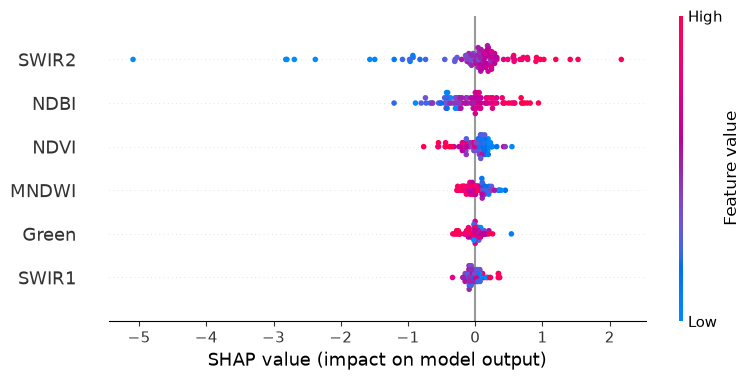

In [25]:
X_shap_test_df = pd.DataFrame(
    X_shap_test,
    columns=feature_names
)

shap.summary_plot(
    rf_shap_test,
    X_shap_test_df,
    show=True
)

## 10. XGBoost SHAP Analysis

The XGBoost model is explained using SHAP's tree-based explainer.

The same 100-observation sample used for the RF analysis is used here
so that the SHAP results of the two models can be compared consistently.

The analysis shows:

- which predictors have the greatest influence on XGBoost predictions,
- whether high or low feature values increase or decrease the predicted LST,
- and how the learned relationships compare with the Random Forest model.

In [26]:
xgb_explainer = shap.TreeExplainer(xgb_model)

xgb_shap_values = xgb_explainer.shap_values(X_shap_test)

print("XGB SHAP shape:", xgb_shap_values.shape)

XGB SHAP shape: (100, 6)


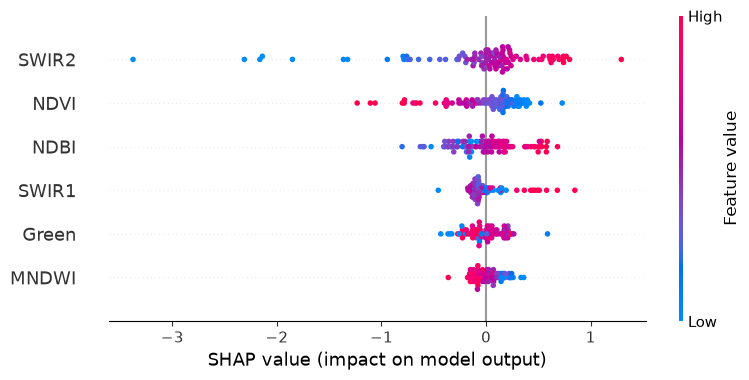

In [27]:
shap.summary_plot(
    xgb_shap_values,
    X_shap_test_df,
    show=True
)

## 11. SHAP Dependence Analysis

The SHAP summary plots identified SWIR2, NDBI, and NDVI as the most
important predictors across the two models.

Dependence plots are used to examine how the SHAP contribution changes
with the actual value of each predictor.

This helps identify the direction and shape of the relationship learned
by each model.

The analysis focuses on SWIR2, NDBI, and NDVI because these predictors
show the strongest and most consistent influence across the RF and
XGBoost models.

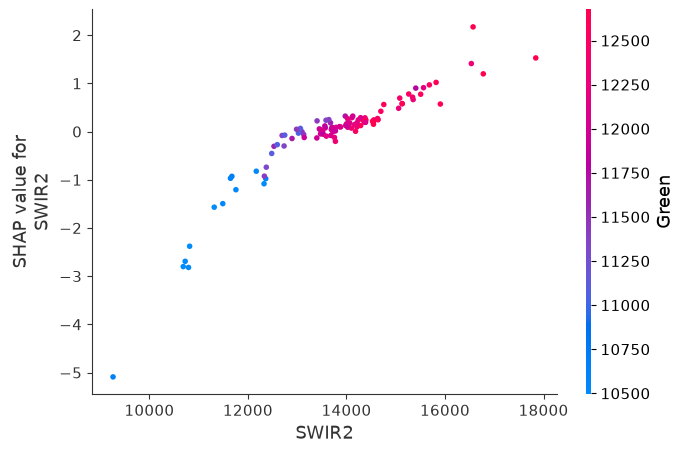

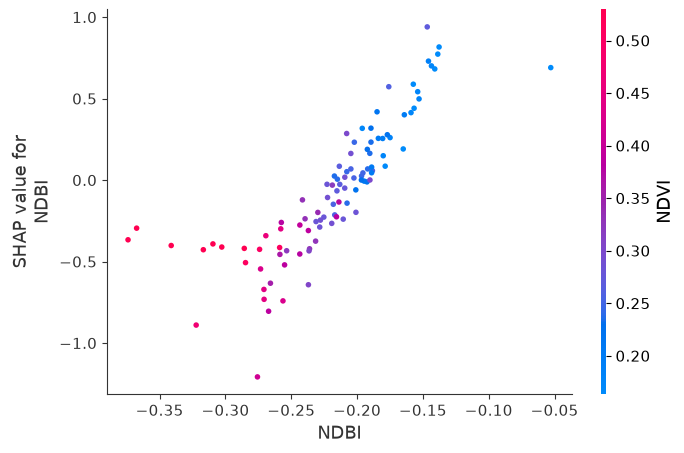

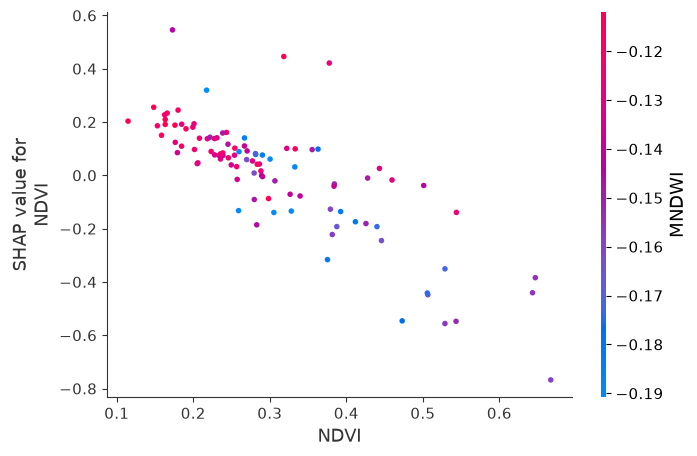

In [28]:
for feature in ["SWIR2", "NDBI", "NDVI"]:
    shap.dependence_plot(
        feature,
        rf_shap_test,
        X_shap_test_df,
        show=True
    )

### XGBoost Dependence Plots

The same three predictors are examined for XGBoost so that their
learned relationships can be compared directly with the Random Forest.

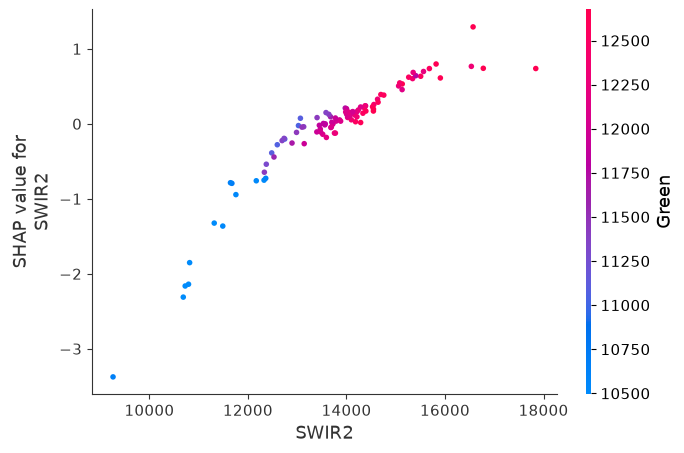

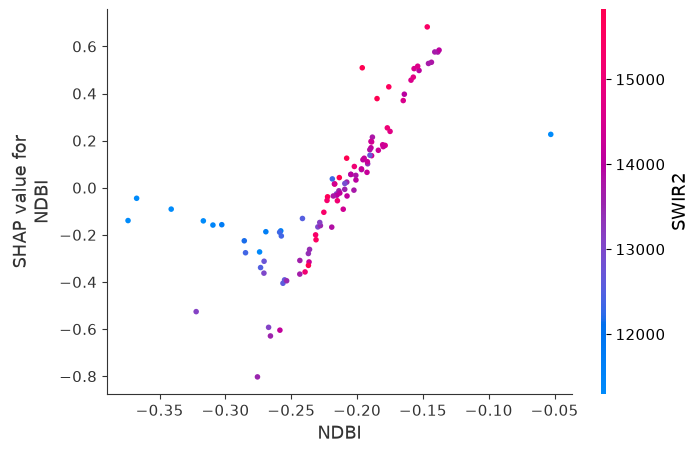

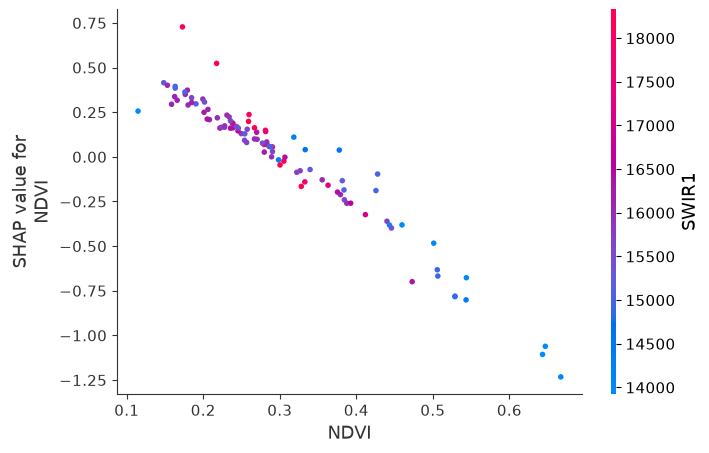

In [29]:
for feature in ["SWIR2", "NDBI", "NDVI"]:
    shap.dependence_plot(
        feature,
        xgb_shap_values,
        X_shap_test_df,
        show=True
    )

## 12. Save SHAP Figures

The SHAP summary and dependence plots are saved in the project's
Lucknow figures directory.

These figures provide visual explanations of how the RF and XGBoost
models use the remote-sensing predictors for LST downscaling.

In [30]:
SHAP_FIG_DIR = PROJECT_DIR / "figures" / "lucknow" / "notebook_7"

SHAP_FIG_DIR.mkdir(parents=True, exist_ok=True)

print("SHAP figure directory:", SHAP_FIG_DIR)

SHAP figure directory: D:\Projects\GeoAI-LST-Downscaling\figures\lucknow\notebook_7


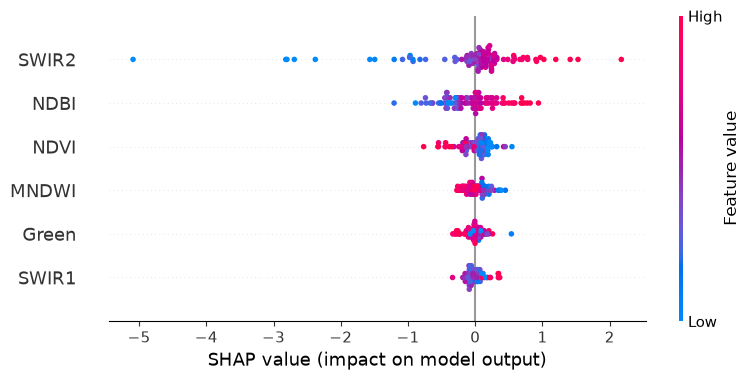

In [31]:
plt.figure()

shap.summary_plot(
    rf_shap_test,
    X_shap_test_df,
    show=False
)

plt.tight_layout()

plt.savefig(
    SHAP_FIG_DIR / "rf_shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

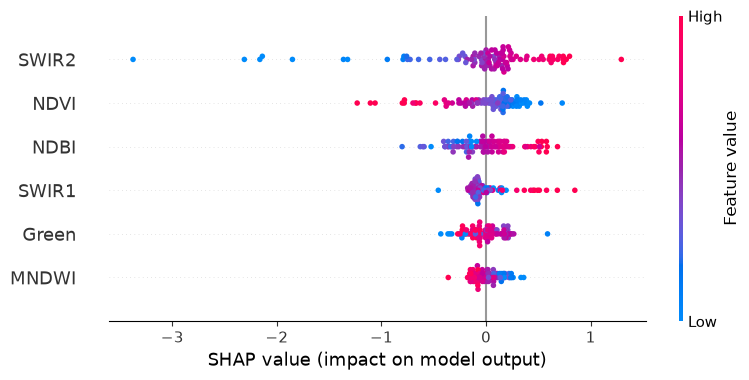

In [32]:
plt.figure()

shap.summary_plot(
    xgb_shap_values,
    X_shap_test_df,
    show=False
)

plt.tight_layout()

plt.savefig(
    SHAP_FIG_DIR / "xgb_shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [33]:
selected_features = ["SWIR2", "NDBI", "NDVI"]

for feature in selected_features:

    # RF
    plt.figure()

    shap.dependence_plot(
        feature,
        rf_shap_test,
        X_shap_test_df,
        show=False
    )

    plt.tight_layout()

    plt.savefig(
        SHAP_FIG_DIR / f"rf_shap_dependence_{feature.lower()}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    # XGB
    plt.figure()

    shap.dependence_plot(
        feature,
        xgb_shap_values,
        X_shap_test_df,
        show=False
    )

    plt.tight_layout()

    plt.savefig(
        SHAP_FIG_DIR / f"xgb_shap_dependence_{feature.lower()}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

print("SHAP figures saved successfully.")

SHAP figures saved successfully.


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

## 13. SHAP Interpretation and Conclusions

SHAP was used to explain how the Random Forest (RF) and XGBoost (XGB)
models use the six remote-sensing predictors for 90 m LST downscaling.

The SHAP summary plots showed strong agreement between the two models
in identifying SWIR2, NDBI, and NDVI as the dominant predictors.

SWIR2 showed the strongest influence in both models. Higher SWIR2
values generally produced positive SHAP contributions, indicating that
they pushed the predicted LST upward, while lower values generally
produced negative contributions.

NDBI also showed a predominantly positive relationship with predicted
LST. Higher NDBI values generally increased the model prediction,
while lower values produced negative contributions. The XGBoost model
showed a particularly clear nonlinear transition in this relationship.

NDVI showed the opposite behaviour. Higher NDVI values generally
produced negative SHAP contributions, while lower NDVI values tended
to push predictions upward. This indicates that the models associate
higher vegetation-related values with lower predicted LST.

The remaining predictors, MNDWI, Green, and SWIR1, had smaller
contributions overall. Their relative importance differed between
the two models. In particular, XGBoost relied more on SWIR1 than the
Random Forest, while MNDWI had greater relative influence in the
Random Forest.

The dependence plots further showed that the relationships learned
by the models were not simply feature rankings. They revealed the
direction and shape of the contribution of the major predictors to
individual predictions.

Overall, the SHAP analysis demonstrates that both models learned
similar dominant relationships from the remote-sensing predictors,
while also showing differences in how individual secondary predictors
were utilized.

### Important limitation

The SHAP analysis was performed on a 100-observation sample because
the saved Random Forest model contains 300 trees and required
substantial computation time for SHAP calculation.

Therefore, the SHAP results should be interpreted as an exploratory
explanation of model behaviour rather than as a statistically
exhaustive characterization of every pixel.

SHAP describes the behaviour of the trained machine-learning models
and does not establish physical causation between the predictors and
LST.